# **QuantReturn: Multi-Model Time-Series Forecasting for Tech Equities**

## Phase 1: Setup

In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
tickers = ["TSLA", "NVDA", "GOOG", "ORCL", "AMD"]

data = yf.download(
    tickers,
    start="2015-01-01",
    end="2024-12-31",
    group_by='ticker'
)


/tmp/ipython-input-4167588943.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  5 of 5 completed


In [ ]:
data.isnull().sum()

Ticker  Price 
GOOG    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
NVDA    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
AMD     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
ORCL    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
TSLA    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
dtype: int64

In [ ]:
data.index.is_monotonic_increasing

True

In [ ]:
data.index.duplicated().sum()

np.int64(0)

In [ ]:
(data.xs("Volume", level=1, axis=1) == 0).sum()

,0
Ticker,
GOOG,0
NVDA,0
AMD,1
ORCL,0
TSLA,0


AMD has one bad data row (volume = 0)

In [ ]:
returns = data.xs("Close", level=1, axis=1).pct_change()

**Why Close Price?**
   - Official settlement price (industry standard)
   - Eliminates intraday noise
   - Stable, widely accepted reference

**Why Daily Returns?**

   - Returns are STATIONARY → ARIMA/ML models require this
   - Prices are NON-STATIONARY (random walk) → violates model assumptions
   - Eliminates long-term trend → focuses on true predictability

In [ ]:
returns

Ticker,GOOG,NVDA,AMD,ORCL,TSLA
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.020845,-0.016890,-0.003745,-0.014024,-0.042041
2015-01-06,-0.023177,-0.030318,-0.011278,-0.010323,0.005664
2015-01-07,-0.001713,-0.002606,-0.019011,0.000232,-0.001562
2015-01-08,0.003153,0.037617,0.011628,0.006025,-0.001564
...,...,...,...,...,...
2024-12-23,0.015703,0.036897,0.045214,-0.003065,0.022657
2024-12-24,0.008062,0.003938,0.013563,0.013421,0.073572
2024-12-26,-0.002379,-0.002068,-0.009740,0.001575,-0.017630


In [ ]:
returns = returns.dropna()

In [ ]:
returns.describe()

Ticker,GOOG,NVDA,AMD,ORCL,TSLA
count,2514.000000,2514.000000,2514.000000,2514.000000,2514.000000
mean,0.000957,0.002714,0.002190,0.000738,0.001979
std,0.017956,0.030621,0.036951,0.017334,0.036009
min,-0.111008,-0.187559,-0.242291,-0.134954,-0.210628
25%,-0.007167,-0.012436,-0.016872,-0.006664,-0.016160
50%,0.001199,0.002652,0.000482,0.000961,0.001264
75%,0.009464,0.017626,0.020277,0.008258,0.019256
max,0.160524,0.298067,0.522901,0.204271,0.219190


In [ ]:
for col in returns.columns:
    print(col, "→", returns[col].idxmax(), "→", returns[col].max())

GOOG → 2015-07-17 00:00:00 → 0.1605241984441126
NVDA → 2016-11-11 00:00:00 → 0.2980668931243746
AMD → 2016-04-22 00:00:00 → 0.5229008335186689
ORCL → 2020-03-13 00:00:00 → 0.2042714531960268
TSLA → 2024-10-24 00:00:00 → 0.21919035070290427


Thus the 52% spike in AMD is NOT linked to the zero-volume corruption

In [ ]:
data_clean = data.copy()

# Drop the zero-volume AMD day
bad_date = "2015-01-02"
data_clean = data_clean.drop(index=bad_date, errors='ignore')

In [ ]:
returns = data_clean.xs("Close", level=1, axis=1).pct_change().dropna()
returns_clean = returns.copy()
returns_clean.columns = [f"{col}_Return" for col in returns_clean.columns]

In [ ]:
data_clean.columns = ['_'.join(col).strip() for col in data_clean.columns]

In [ ]:
data_aligned = data_clean.loc[returns_clean.index]
data_with_returns = data_aligned.join(returns_clean, how="inner")

In [ ]:
data_with_returns.shape
data_with_returns.columns

Index(['GOOG_Open', 'GOOG_High', 'GOOG_Low', 'GOOG_Close', 'GOOG_Volume',
       'NVDA_Open', 'NVDA_High', 'NVDA_Low', 'NVDA_Close', 'NVDA_Volume',
       'AMD_Open', 'AMD_High', 'AMD_Low', 'AMD_Close', 'AMD_Volume',
       'ORCL_Open', 'ORCL_High', 'ORCL_Low', 'ORCL_Close', 'ORCL_Volume',
       'TSLA_Open', 'TSLA_High', 'TSLA_Low', 'TSLA_Close', 'TSLA_Volume',
       'GOOG_Return', 'NVDA_Return', 'AMD_Return', 'ORCL_Return',
       'TSLA_Return'],
      dtype='object')

DATA PREPARATION: Three Dataset Subsets

1. data_clean: Raw OHLCV data (cleaned)

2. returns_clean: Daily returns calculated from Close prices
   
3. data_with_returns: Combined features + target variable

## Phase 2: EDA & Stationarity Testing

In [ ]:
data_clean.columns

Index(['GOOG_Open', 'GOOG_High', 'GOOG_Low', 'GOOG_Close', 'GOOG_Volume',
       'NVDA_Open', 'NVDA_High', 'NVDA_Low', 'NVDA_Close', 'NVDA_Volume',
       'AMD_Open', 'AMD_High', 'AMD_Low', 'AMD_Close', 'AMD_Volume',
       'ORCL_Open', 'ORCL_High', 'ORCL_Low', 'ORCL_Close', 'ORCL_Volume',
       'TSLA_Open', 'TSLA_High', 'TSLA_Low', 'TSLA_Close', 'TSLA_Volume'],
      dtype='object')

Price Trends

In [ ]:
import plotly.graph_objects as go

close_cols = {
    "ORCL": "ORCL_Close",
    "AMD": "AMD_Close",
    "GOOG": "GOOG_Close",
    "TSLA": "TSLA_Close",
    "NVDA": "NVDA_Close"
}

fig = go.Figure()

for ticker, col in close_cols.items():
    fig.add_trace(go.Scatter(
        x=data_clean.index,
        y=data_clean[col],
        mode='lines',
        name=ticker,
        line=dict(width=1.5)
    ))

fig.update_layout(
    title="Daily Close Prices (All Tickers)",
    xaxis_title="Date",
    yaxis_title="Price",
    hovermode="x unified",
    template="plotly_dark",
    height=600
)

fig.update_xaxes(rangeslider_visible=True)

fig.show()

Returns Distribution

In [ ]:
import plotly.express as px

fig = px.histogram(
    returns_clean,
    x="ORCL_Return",
    nbins=100,
    title="ORCL: Returns Distribution",
    color_discrete_sequence=["#1f77b4"]
)
fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
fig = px.histogram(
    returns_clean,
    x="AMD_Return",
    nbins=100,
    title="AMD: Returns Distribution",
    color_discrete_sequence=["#d62728"]
)
fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
fig = px.histogram(
    returns_clean,
    x="GOOG_Return",
    nbins=100,
    title="GOOG: Returns Distribution",
    color_discrete_sequence=["#2ca02c"]
)
fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
fig = px.histogram(
    returns_clean,
    x="TSLA_Return",
    nbins=100,
    title="TSLA: Returns Distribution",
    color_discrete_sequence=["#ff7f0e"]
)
fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
fig = px.histogram(
    returns_clean,
    x="NVDA_Return",
    nbins=100,
    title="NVDA: Returns Distribution",
    color_discrete_sequence=["#9467bd"]
)
fig.update_layout(template="plotly_dark")
fig.show()

Voltality Analysis

In [ ]:
# 20-day rolling volatility for each ticker
for col in returns_clean.columns:
    ticker = col.replace("_Return", "")
    data_with_returns[f"{ticker}_RollingVol20"] = returns_clean[col].rolling(20).std()

In [ ]:
import plotly.express as px

fig = px.line(
    data_with_returns,
    y="ORCL_RollingVol20",
    title="ORACLE: 20-Day Rolling Volatility",
    color_discrete_sequence=["#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    data_with_returns,
    y="AMD_RollingVol20",
    title="AMD: 20-Day Rolling Volatility",
    color_discrete_sequence=["#1f77b4"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    data_with_returns,
    y="GOOG_RollingVol20",
    title="GOOGLE: 20-Day Rolling Volatility",
    color_discrete_sequence=["#2ca02c"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    data_with_returns,
    y="TSLA_RollingVol20",
    title="TSLA: 20-Day Rolling Volatility",
    color_discrete_sequence=["#ff7f0e"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    data_with_returns,
    y="NVDA_RollingVol20",
    title="NVDIA: 20-Day Rolling Volatility",
    color_discrete_sequence=["#9467bd"]
)

fig.update_layout(template="plotly_dark")
fig.show()

Cross-Asset Correlation

In [ ]:
corr_matrix = returns_clean.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap of Daily Returns",
)

fig.update_layout(
    template="plotly_dark",
    width=700,
    height=600
)

fig.show()

Volume-Return Relationship

In [ ]:
# Volume % change
vol_change_orcl = data_clean["ORCL_Volume"].pct_change() * 100

df_orcl = pd.DataFrame({
    "Return": returns_clean["ORCL_Return"],
    "VolumeChange": vol_change_orcl
})

fig = px.scatter(
    df_orcl,
    x="VolumeChange",
    y="Return",
    title="ORCL: Volume Change (%) vs Return",
    labels={"VolumeChange": "Volume % Change", "Return": "Daily Return"},
    opacity=0.7,
    color_discrete_sequence=["#1f77b4"]
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

In [ ]:
vol_change_amd = data_clean["AMD_Volume"].pct_change() * 100

df_amd = pd.DataFrame({
    "Return": returns_clean["AMD_Return"],
    "VolumeChange": vol_change_amd
})

fig = px.scatter(
    df_amd,
    x="VolumeChange",
    y="Return",
    title="AMD: Volume Change (%) vs Return",
    labels={"VolumeChange": "Volume % Change", "Return": "Daily Return"},
    opacity=0.7,
    color_discrete_sequence=["#d62728"]
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

In [ ]:
vol_change_goog = data_clean["GOOG_Volume"].pct_change() * 100

df_goog = pd.DataFrame({
    "Return": returns_clean["GOOG_Return"],
    "VolumeChange": vol_change_goog
})

fig = px.scatter(
    df_goog,
    x="VolumeChange",
    y="Return",
    title="GOOG: Volume Change (%) vs Return",
    labels={"VolumeChange": "Volume % Change", "Return": "Daily Return"},
    opacity=0.7,
    color_discrete_sequence=["#2ca02c"]
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

In [ ]:
vol_change_tsla = data_clean["TSLA_Volume"].pct_change() * 100

df_tsla = pd.DataFrame({
    "Return": returns_clean["TSLA_Return"],
    "VolumeChange": vol_change_tsla
})

fig = px.scatter(
    df_tsla,
    x="VolumeChange",
    y="Return",
    title="TSLA: Volume Change (%) vs Return",
    labels={"VolumeChange": "Volume % Change", "Return": "Daily Return"},
    opacity=0.7,
    color_discrete_sequence=["#ff7f0e"]
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

In [ ]:
vol_change_nvda = data_clean["NVDA_Volume"].pct_change() * 100

df_nvda = pd.DataFrame({
    "Return": returns_clean["NVDA_Return"],
    "VolumeChange": vol_change_nvda
})

fig = px.scatter(
    df_nvda,
    x="VolumeChange",
    y="Return",
    title="NVDA: Volume Change (%) vs Return",
    labels={"VolumeChange": "Volume % Change", "Return": "Daily Return"},
    opacity=0.7,
    color_discrete_sequence=["#9467bd"]
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

Volume Spike Detection

In [ ]:
import numpy as np

for t in ["ORCL", "TSLA", "NVDA", "AMD", "GOOG"]:
    vol = data_with_returns[f"{t}_Volume"]
    z = (vol - vol.rolling(20).mean()) / vol.rolling(20).std()
    data_with_returns[f"{t}_VolumeSpike"] = (z > 3).astype(int)

In [ ]:
spike_counts = data_with_returns[[f"{t}_VolumeSpike" for t in ["ORCL","TSLA","NVDA","AMD","GOOG"]]].sum()
print(spike_counts)

ORCL_VolumeSpike    73
TSLA_VolumeSpike    46
NVDA_VolumeSpike    58
AMD_VolumeSpike     55
GOOG_VolumeSpike    72
dtype: int64


In [ ]:
import plotly.express as px

fig = px.scatter(
    data_with_returns,
    x=data_with_returns.index,
    y="ORCL_Volume",
    color="ORCL_VolumeSpike",
    title="ORCL Volume with Spike Detection",
    color_continuous_scale=["#1f77b4", "#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    data_with_returns,
    x=data_with_returns.index,
    y="GOOG_Volume",
    color="GOOG_VolumeSpike",
    title="GOOGLE Volume with Spike Detection",
    color_continuous_scale=["#1f77b4", "#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    data_with_returns,
    x=data_with_returns.index,
    y="AMD_Volume",
    color="AMD_VolumeSpike",
    title="AMD Volume with Spike Detection",
    color_continuous_scale=["#1f77b4", "#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    data_with_returns,
    x=data_with_returns.index,
    y="NVDA_Volume",
    color="NVDA_VolumeSpike",
    title="NVDIA Volume with Spike Detection",
    color_continuous_scale=["#1f77b4", "#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    data_with_returns,
    x=data_with_returns.index,
    y="TSLA_Volume",
    color="TSLA_VolumeSpike",
    title="TESLA Volume with Spike Detection",
    color_continuous_scale=["#1f77b4", "#EF553B"]
)

fig.update_layout(template="plotly_dark")
fig.show()

Stationarity Testing (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller

return_cols = {
    "ORCL": "ORCL_Return",
    "AMD": "AMD_Return",
    "GOOG": "GOOG_Return",
    "TSLA": "TSLA_Return",
    "NVDA": "NVDA_Return"
}

for ticker, col in return_cols.items():
    series = returns_clean[col].dropna()
    adf_result = adfuller(series)
    p_value = adf_result[1]

    print(f"\n{ticker} — ADF Test")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print("→ Stationary (reject H0)")
    else:
        print("→ Not stationary (fail to reject H0)")


ORCL — ADF Test
ADF Statistic: -16.7762
p-value: 0.0000
→ Stationary (reject H0)

AMD — ADF Test
ADF Statistic: -29.7183
p-value: 0.0000
→ Stationary (reject H0)

GOOG — ADF Test
ADF Statistic: -17.3332
p-value: 0.0000
→ Stationary (reject H0)

TSLA — ADF Test
ADF Statistic: -50.1239
p-value: 0.0000
→ Stationary (reject H0)

NVDA — ADF Test
ADF Statistic: -16.2860
p-value: 0.0000
→ Stationary (reject H0)


Rolling Stats Analysis

In [ ]:
roll_mean_orcl = returns_clean["ORCL_Return"].rolling(20).mean()
roll_std_orcl = returns_clean["ORCL_Return"].rolling(20).std()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=roll_mean_orcl.index,
    y=roll_mean_orcl,
    name="Rolling Mean (20d)",
    line=dict(color="#1f77b4")
))

fig.add_trace(go.Scatter(
    x=roll_std_orcl.index,
    y=roll_std_orcl,
    name="Rolling Std (20d)",
    line=dict(color="#d62728")
))

fig.update_layout(
    title="ORCL: Rolling Mean & Rolling Std (20-Day)",
    xaxis_title="Date",
    yaxis_title="Value",
    template="plotly_dark",
    height=500
)

fig.show()

In [ ]:
roll_mean_amd = returns_clean["AMD_Return"].rolling(20).mean()
roll_std_amd = returns_clean["AMD_Return"].rolling(20).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_mean_amd.index, y=roll_mean_amd, name="Rolling Mean", line=dict(color="#1f77b4")))
fig.add_trace(go.Scatter(x=roll_std_amd.index, y=roll_std_amd, name="Rolling Std", line=dict(color="#d62728")))

fig.update_layout(title="AMD: Rolling Mean & Std (20d)", template="plotly_dark", height=500)
fig.show()

In [ ]:
roll_mean_goog = returns_clean["GOOG_Return"].rolling(20).mean()
roll_std_goog = returns_clean["GOOG_Return"].rolling(20).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_mean_goog.index, y=roll_mean_goog, name="Rolling Mean", line=dict(color="#1f77b4")))
fig.add_trace(go.Scatter(x=roll_std_goog.index, y=roll_std_goog, name="Rolling Std", line=dict(color="#d62728")))

fig.update_layout(title="GOOG: Rolling Mean & Std (20d)", template="plotly_dark", height=500)
fig.show()

In [ ]:
roll_mean_tsla = returns_clean["TSLA_Return"].rolling(20).mean()
roll_std_tsla = returns_clean["TSLA_Return"].rolling(20).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_mean_tsla.index, y=roll_mean_tsla, name="Rolling Mean", line=dict(color="#1f77b4")))
fig.add_trace(go.Scatter(x=roll_std_tsla.index, y=roll_std_tsla, name="Rolling Std", line=dict(color="#d62728")))

fig.update_layout(title="TSLA: Rolling Mean & Std (20d)", template="plotly_dark", height=500)
fig.show()

In [ ]:
roll_mean_nvda = returns_clean["NVDA_Return"].rolling(20).mean()
roll_std_nvda = returns_clean["NVDA_Return"].rolling(20).std()

fig = go.Figure()
fig.add_trace(go.Scatter(x=roll_mean_nvda.index, y=roll_mean_nvda, name="Rolling Mean", line=dict(color="#1f77b4")))
fig.add_trace(go.Scatter(x=roll_std_nvda.index, y=roll_std_nvda, name="Rolling Std", line=dict(color="#d62728")))

fig.update_layout(title="NVDA: Rolling Mean & Std (20d)", template="plotly_dark", height=500)
fig.show()

Autocorrelation Analysis

We determine ARIMA(p,d,q) from **TSLA ACF/PACF analysis** and apply the same
parameters (later, after  splitting data) to GOOG and ORCL, as tech stocks exhibit similar return autocorrelation
structures. This ensures fair comparison: same model, different data.

**Comparison:** TSLA vs GOOG vs ORCL with identical ARIMA parameters

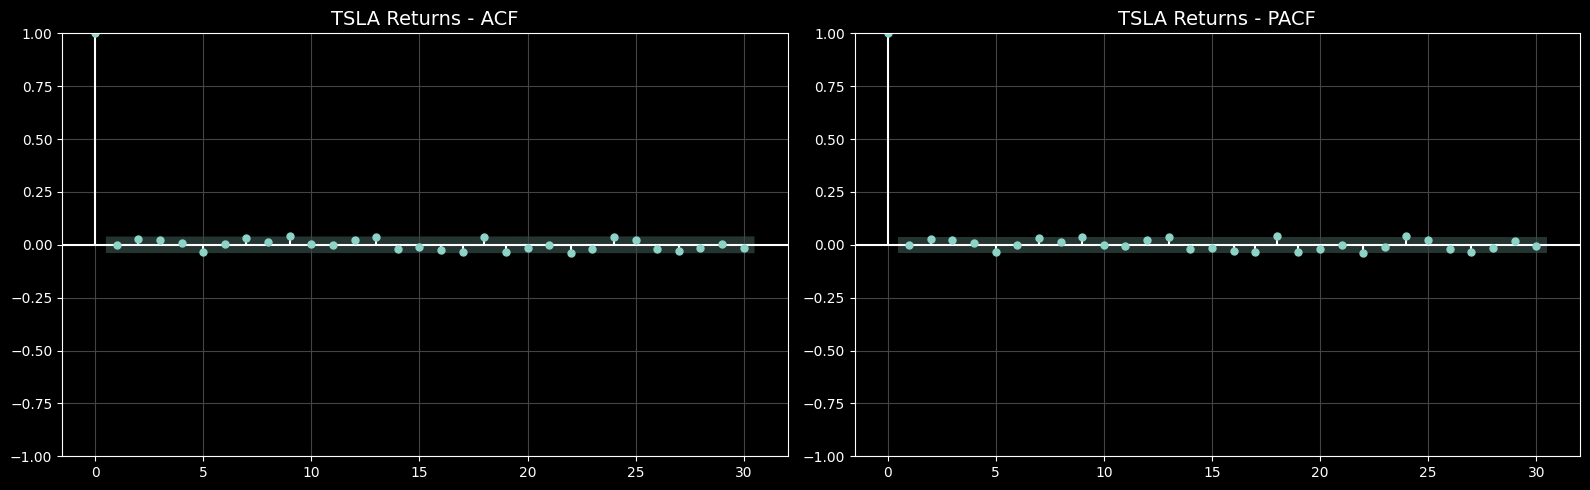

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

tsla_returns = returns_clean["TSLA_Return"].dropna()

plt.style.use("dark_background")

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(tsla_returns, lags=30, alpha=0.05, ax=ax[0])
ax[0].set_title("TSLA Returns - ACF", fontsize=14, color="white")
ax[0].grid(color="#444444")
ax[0].tick_params(colors="white")

# PACF
plot_pacf(tsla_returns, lags=30, alpha=0.05, method="ywm", ax=ax[1])
ax[1].set_title("TSLA Returns - PACF", fontsize=14, color="white")
ax[1].grid(color="#444444")
ax[1].tick_params(colors="white")

plt.tight_layout()
plt.show()


ACF Plot:
- All spikes within confidence bands
- No significant autocorrelation detected
- Suggests: q = 0 or 1

PACF Plot:
- All spikes within confidence bands
- No significant partial autocorrelation detected
- Suggests: p = 0 or 1

Conclusion:
TSLA returns exhibit minimal autocorrelation (typical for efficient equity markets).
We will test simple ARIMA orders in the modeling section.

## Phase 3: Feature Engineering

In [ ]:
tickers = ["ORCL", "AMD", "GOOG", "TSLA", "NVDA"]

XLK is a tech sector ETF that represents overall market movement. Adding it as a feature
helps our models understand how the entire tech sector is performing, not just individual stocks.

In [ ]:
import yfinance as yf

# Download XLK OHLCV
xlk = yf.download("XLK", start="2015-01-01", end="2024-12-31")

/tmp/ipython-input-136294374.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
xlk.columns = [col[0] for col in xlk.columns]

In [ ]:
data_with_returns = data_with_returns.join(
    xlk[['Close','Volume']].rename(
        columns={'Close':'XLK_Close','Volume':'XLK_Volume'}
    ),
    how="inner"
)

# Add XLK_Return
data_with_returns["XLK_Return"] = xlk["Close"].pct_change().reindex(data_with_returns.index)

In [ ]:
[x for x in data_with_returns.columns if "XLK" in x]

['XLK_Close', 'XLK_Volume', 'XLK_Return']

Lagged Features

In [ ]:
lag_periods = [1, 2, 5, 10]

for t in tickers:
    ret = f"{t}_Return"
    for lag in lag_periods:
        data_with_returns[f"{t}_lag_{lag}"] = data_with_returns[ret].shift(lag)

Rolling Statistics

In [ ]:
for t in tickers:
    ret = f"{t}_Return"

    # Rolling means
    data_with_returns[f"{t}_rollmean_5"] = data_with_returns[ret].rolling(5).mean()
    data_with_returns[f"{t}_rollmean_10"] = data_with_returns[ret].rolling(10).mean()
    data_with_returns[f"{t}_rollmean_20"] = data_with_returns[ret].rolling(20).mean()

    # Rolling std
    data_with_returns[f"{t}_rollstd_10"] = data_with_returns[ret].rolling(10).std()
    data_with_returns[f"{t}_rollstd_20"] = data_with_returns[ret].rolling(20).std()

Volume Features

In [ ]:
for t in tickers:
    vol = f"{t}_Volume"

    data_with_returns[f"{t}_vol_pct_change"] = data_with_returns[vol].pct_change()
    data_with_returns[f"{t}_vol_rollmean_10"] = data_with_returns[vol].rolling(10).mean()

Technical Indicators (SMA, RSI, MACD)

In [ ]:
#SMA20, SMA50, Price/SMA Ratios
for t in tickers:
    close = f"{t}_Close"

    data_with_returns[f"{t}_SMA20"] = data_with_returns[close].rolling(20).mean()
    data_with_returns[f"{t}_SMA50"] = data_with_returns[close].rolling(50).mean()

    data_with_returns[f"{t}_price_sma20"] = data_with_returns[close] / data_with_returns[f"{t}_SMA20"]
    data_with_returns[f"{t}_price_sma50"] = data_with_returns[close] / data_with_returns[f"{t}_SMA50"]

In [ ]:
#RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

for t in tickers:
    close = f"{t}_Close"
    data_with_returns[f"{t}_RSI"] = compute_rsi(data_with_returns[close])

In [ ]:
#MACD (12/26 EMA + 9 EMA Signal + Histogram)
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

for t in tickers:
    close = f"{t}_Close"

    ema12 = ema(data_with_returns[close], 12)
    ema26 = ema(data_with_returns[close], 26)

    macd = ema12 - ema26
    signal = ema(macd, 9)
    hist = macd - signal

    data_with_returns[f"{t}_MACD"] = macd
    data_with_returns[f"{t}_MACD_signal"] = signal
    data_with_returns[f"{t}_MACD_hist"] = hist

Calendar Features

In [ ]:
data_with_returns["day_of_week"] = data_with_returns.index.dayofweek
data_with_returns["month"] = data_with_returns.index.month
data_with_returns["quarter"] = data_with_returns.index.quarter
data_with_returns["is_month_end"] = data_with_returns.index.is_month_end.astype(int)
data_with_returns["is_month_start"] = data_with_returns.index.is_month_start.astype(int)

/tmp/ipython-input-1223183044.py:1: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-1223183044.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-1223183044.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipython-input-1223183044.py:4: PerformanceWarning:

In [ ]:
data_model = data_with_returns.dropna().copy()

## Phase 4: Train-Test-Split & Baseline Models

In [ ]:
data_with_returns.isna().sum().sum()

np.int64(1285)

In [ ]:
null_counts = data_with_returns.isna().sum()
null_counts[null_counts > 0]

,0
GOOG_RollingVol20,19
NVDA_RollingVol20,19
AMD_RollingVol20,19
ORCL_RollingVol20,19
TSLA_RollingVol20,19
...,...
ORCL_RSI,14
AMD_RSI,14
GOOG_RSI,14
TSLA_RSI,14


In [ ]:
data_model = data_with_returns.dropna()

#### Multi-Stock Modeling: TSLA, GOOG, ORCL

As per the assignment requirement to compare ARIMA and Gradient Boosting models,
we build and evaluate both on three representative tech stocks: Tesla, Google, and Oracle.

In [ ]:
y_tsla = data_with_returns["TSLA_Return"].shift(-1)
y_goog = data_with_returns["GOOG_Return"].shift(-1)
y_orcl = data_with_returns["ORCL_Return"].shift(-1)

In [ ]:
# Drop raw OHLCV columns
cols_to_drop = [c for c in data_with_returns.columns if c.endswith(("_Open","_High","_Low","_Close","_Volume"))]

X = data_with_returns.drop(columns=cols_to_drop)

In [ ]:
# Drop raw OHLCV columns
cols_to_drop = [c for c in data_with_returns.columns if c.endswith(("_Open","_High","_Low","_Close","_Volume"))]

In [ ]:
X = X.iloc[:-1]
y_tsla = y_tsla.iloc[:-1]
y_goog = y_goog.iloc[:-1]
y_orcl = y_orcl.iloc[:-1]

In [ ]:
print(f"X shape: {X.shape}")
print(f"y_tsla shape: {y_tsla.shape}")
print(f"y_goog shape: {y_goog.shape}")
print(f"y_orcl shape: {y_orcl.shape}")

X shape: (2512, 116)
y_tsla shape: (2512,)
y_goog shape: (2512,)
y_orcl shape: (2512,)


Chronological Train-Test-Split

In [ ]:
# TSLA
X_train = X[X.index.year <= 2022]
y_train_tsla = y_tsla[y_tsla.index.year <= 2022]
X_test = X[X.index.year >= 2023]
y_test_tsla = y_tsla[y_tsla.index.year >= 2023]

# GOOG
y_train_goog = y_goog[y_goog.index.year <= 2022]
y_test_goog = y_goog[y_goog.index.year >= 2023]

# ORCL
# ORCL
y_train_orcl = y_orcl[y_orcl.index.year <= 2022]
y_test_orcl = y_orcl[y_orcl.index.year >= 2023]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"TSLA - train: {y_train_tsla.shape}, test: {y_test_tsla.shape}")
print(f"GOOG - train: {y_train_goog.shape}, test: {y_test_goog.shape}")
print(f"ORCL - train: {y_train_orcl.shape}, test: {y_test_orcl.shape}")

X_train: (2012, 116), X_test: (500, 116)
TSLA - train: (2012,), test: (500,)
GOOG - train: (2012,), test: (500,)
ORCL - train: (2012,), test: (500,)


Baseline 1: Naive Forecast (Tomorrow = Today) For 3 Stocks

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

stocks = {
    "TSLA": y_test_tsla,
    "GOOG": y_test_goog,
    "ORCL": y_test_orcl
}

print("Naive Forecast Results (2023 test period) \n")
results_naive = []

for ticker, y_test in stocks.items():
    # Predict: today's return repeats tomorrow
    y_pred = y_test.shift(1)

    # Drop the first NaN row
    mask = y_pred.notna()
    rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    mae  = mean_absolute_error(y_test[mask], y_pred[mask])

    results_naive.append({"Ticker": ticker, "RMSE": rmse, "MAE": mae})
    print(f"{ticker:5} → RMSE: {rmse:.5f}   |   MAE: {mae:.5f}")


Naive Forecast Results (2023 test period) 

TSLA  → RMSE: 0.05135   |   MAE: 0.03868
GOOG  → RMSE: 0.02547   |   MAE: 0.01882
ORCL  → RMSE: 0.02816   |   MAE: 0.01828


Baseline 2: 5-Day Moving Average of Returns

In [ ]:
print("\n 5-Day Moving Average Forecast Results \n")
results_ma5 = []

for ticker, y_test in stocks.items():
    y_pred = y_test.rolling(window=5).mean().shift(1)

    # Drop rows where rolling mean is NaN (first 5 rows + 1 shift)
    mask = y_pred.notna()
    rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    mae  = mean_absolute_error(y_test[mask], y_pred[mask])

    results_ma5.append({"Ticker": ticker, "RMSE": rmse, "MAE": mae})
    print(f"{ticker:5} → RMSE: {rmse:.5f}   |   MAE: {mae:.5f}")
    ma5_df = pd.DataFrame(results_ma5).set_index("Ticker").round(5)




 5-Day Moving Average Forecast Results 

TSLA  → RMSE: 0.03992   |   MAE: 0.02945
GOOG  → RMSE: 0.02049   |   MAE: 0.01538
ORCL  → RMSE: 0.02183   |   MAE: 0.01471


Baseline 3: Linear Regression (Lagged Only)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Define how many lags you're using (change this if you used more than just TSLA_lag*)
lag_features = [col for col in X.columns if col.startswith(('TSLA_lag', 'GOOG_lag', 'ORCL_lag'))]
print(f"Using {len(lag_features)} lag features across all stocks")

stocks_dict = {
    "TSLA": {"X_train": X_train[X_train.index.year < 2023],
             "X_test":  X_test[X_test.index.year >= 2023],
             "y_train": y_train_tsla,
             "y_test":  y_test_tsla},
    "GOOG": {"X_train": X_train[X_train.index.year < 2023],
             "X_test":  X_test[X_test.index.year >= 2023],
             "y_train": y_train_goog,
             "y_test":  y_test_goog},
    "ORCL": {"X_train": X_train[X_train.index.year < 2023],
             "X_test":  X_test[X_test.index.year >= 2023],
             "y_train": y_train_orcl,
             "y_test":  y_test_orcl}
}

print("\nLinear Regression (Lags Only) → Out-of-sample (2023–present)\n")
results_lr = []

for ticker, data in stocks_dict.items():
    # Select only this stock's lag features
    ticker_lag_cols = [col for col in lag_features if col.startswith(ticker)]
    X_train_lr = data["X_train"][ticker_lag_cols]
    X_test_lr  = data["X_test"][ticker_lag_cols]

    # Drop rows with any NaN (from lagging)
    train_mask = X_train_lr.notna().all(axis=1)
    test_mask  = X_test_lr.notna().all(axis=1)

    X_train_clean = X_train_lr[train_mask]
    y_train_clean = data["y_train"][train_mask]

    X_test_clean  = X_test_lr[test_mask]
    y_test_clean  = data["y_test"][test_mask]

    # Fit & predict
    lr = LinearRegression()
    lr.fit(X_train_clean, y_train_clean)
    y_pred_lr = lr.predict(X_test_clean)

    rmse_lr = np.sqrt(mean_squared_error(y_test_clean, y_pred_lr))
    mae_lr  = mean_absolute_error(y_test_clean, y_pred_lr)

    results_lr.append({"Ticker": ticker, "RMSE": rmse_lr, "MAE": mae_lr})

    print(f"{ticker:5} → RMSE: {rmse_lr:.5f}   |   MAE: {mae_lr:.5f}")

Using 12 lag features across all stocks

Linear Regression (Lags Only) → Out-of-sample (2023–present)

TSLA  → RMSE: 0.03677   |   MAE: 0.02688
GOOG  → RMSE: 0.01841   |   MAE: 0.01326
ORCL  → RMSE: 0.01981   |   MAE: 0.01260


Comparison table

In [ ]:
comparison = pd.concat([
    pd.DataFrame(results_naive).set_index("Ticker").add_suffix(" (Naive)"),
    pd.DataFrame(results_ma5).set_index("Ticker").add_suffix(" (5-Day MA)"),
    pd.DataFrame(results_lr).set_index("Ticker").add_suffix(" (LinReg Lags)")
], axis=1)

comparison = comparison[[
    "RMSE (Naive)", "MAE (Naive)",
    "RMSE (5-Day MA)", "MAE (5-Day MA)",
    "RMSE (LinReg Lags)", "MAE (LinReg Lags)"
]]

display(comparison)

,RMSE (Naive),MAE (Naive),RMSE (5-Day MA),MAE (5-Day MA),RMSE (LinReg Lags),MAE (LinReg Lags)
Ticker,,,,,,
TSLA,0.051352,0.038683,0.039920,0.029452,0.036766,0.026877
GOOG,0.025469,0.018822,0.020487,0.015380,0.018409,0.013265
ORCL,0.028159,0.018283,0.021830,0.014712,0.019811,0.012597


## Phase 5: Modelling

ARIMA Parameter Determination

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Extract price data for TSLA (reference stock for parameter determination)
tsla_price_train = data_clean["TSLA_Close"][data_clean.index.year <= 2022]
tsla_price_test = data_clean["TSLA_Close"][data_clean.index.year >= 2023]

# Grid search for best (p,d,q)
candidate_orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (1,1,2), (2,1,1)]
best_rmse = float("inf")
best_order = None
results = []

print("Grid Search Results:")
print("=" * 50)

for order in candidate_orders:
    try:
        model = ARIMA(tsla_price_train, order=order).fit()
        pred = model.forecast(steps=len(tsla_price_test))
        pred.index = tsla_price_test.index
        rmse = np.sqrt(mean_squared_error(tsla_price_test, pred))
        results.append({"Order": order, "RMSE": rmse})
        print(f"ARIMA{order}: RMSE = {rmse:.6f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_order = order
    except Exception as e:
        print(f"ARIMA{order}: Failed - {str(e)[:30]}")

print(f" Best Order: ARIMA{best_order} with RMSE: {best_rmse:.6f}")

Grid Search Results:
ARIMA(0, 1, 0): RMSE = 116.118259


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the 

ARIMA(1, 1, 0): RMSE = 116.160820


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been pro

ARIMA(0, 1, 1): RMSE = 116.171289


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been pro

ARIMA(1, 1, 1): RMSE = 116.105876


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been pro

ARIMA(1, 1, 2): RMSE = 116.084990
ARIMA(2, 1, 1): RMSE = 116.084830
 Best Order: ARIMA(2, 1, 1) with RMSE: 116.084830


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



Grid search on TSLA price data (2015-2022) determined optimal parameters:

Best Order: ARIMA(2, 1, 1)
- p = 2 (AR order, from PACF analysis)
- d = 1 (differencing for stationarity)
- q = 1 (MA order, from ACF analysis)
- RMSE: 116.08

Train ARIMA on All 3 Stocks

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

best_order = (2, 1, 1)

arima_results = []

# Train ARIMA on all 3 stocks
for stock in ["TSLA", "GOOG", "ORCL"]:
    # Extract price data
    price_train = data_clean[f"{stock}_Close"][data_clean.index.year <= 2022]
    price_test = data_clean[f"{stock}_Close"][data_clean.index.year >= 2023]

    # Train ARIMA
    model = ARIMA(price_train, order=best_order).fit()
    pred = model.forecast(steps=len(price_test))
    pred.index = price_test.index

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(price_test, pred))
    mae = mean_absolute_error(price_test, pred)
    mape = np.mean(np.abs((price_test - pred) / (np.abs(price_test) + 1e-8))) * 100

    arima_results.append({
        "Stock": stock,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

    print(f"{stock}: RMSE={rmse:.6f}, MAE={mae:.6f}, MAPE={mape:.4f}%")

# Create results table
arima_df = pd.DataFrame(arima_results)
print("ARIMA(2,1,1) Results Across All Stocks:")
print(arima_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the 

TSLA: RMSE=116.084830, MAE=100.718885, MAPE=41.8711%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been pro

GOOG: RMSE=60.047690, MAE=53.292375, MAPE=34.9930%
ORCL: RMSE=49.658348, MAE=41.298553, MAPE=31.2478%
ARIMA(2,1,1) Results Across All Stocks:
Stock       RMSE        MAE      MAPE
 TSLA 116.084830 100.718885 41.871074
 GOOG  60.047690  53.292375 34.992954
 ORCL  49.658348  41.298553 31.247752


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



Train LightGBM on all 3 stocks

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 63,
    "learning_rate": 0.03,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1
}

lgb_results = []

for stock in ["TSLA", "GOOG", "ORCL"]:
    y_train = eval(f"y_train_{stock.lower()}")
    y_test = eval(f"y_test_{stock.lower()}")

    train_data = lgb.Dataset(X_train, label=y_train)
    test_data = lgb.Dataset(X_test, label=y_test)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[test_data],
        num_boost_round=500,
        callbacks=[lgb.log_evaluation(period=0)]
    )

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (np.abs(y_test) + 1e-8))) * 100

    lgb_results.append({
        "Stock": stock,
        "RMSE": round(rmse, 6),
        "MAE": round(mae, 6),
        "MAPE": round(mape, 6)
    })

lgb_results_df = pd.DataFrame(lgb_results)
lgb_results_df


,Stock,RMSE,MAE,MAPE
0,TSLA,0.039220,0.028789,197.121003
1,GOOG,0.020005,0.014741,199.045971
2,ORCL,0.021278,0.014289,321974.886886


Hyperparameter Tuning

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import ParameterGrid
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

param_grid = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.03, 0.05],
    'feature_fraction': [0.8, 0.9],
    'bagging_fraction': [0.8, 0.9],
    'max_depth': [-1, 10]
}

best_models = {}
tuning_results = []

for stock in ["TSLA", "GOOG", "ORCL"]:
    y_train = eval(f"y_train_{stock.lower()}")
    train_data = lgb.Dataset(X_train, label=y_train, free_raw_data=False)

    best_rmse = np.inf
    best_params = None
    best_iter = 0

    for params in ParameterGrid(param_grid):
        params = params.copy()
        params.update({
            "objective": "regression",
            "metric": "rmse",
            "verbosity": -1,
            "seed": 42
        })

        cv_res = lgb.cv(
            params,
            train_data,
            nfold=5,
            num_boost_round=2000,
            stratified=False,
            callbacks=[lgb.early_stopping(50, verbose=False)],
            return_cvbooster=False
        )

        current_rmse = min(cv_res['valid rmse-mean'])
        current_iter = len(cv_res['valid rmse-mean'])

        if current_rmse < best_rmse:
            best_rmse = current_rmse
            best_params = params
            best_iter = current_iter

    model = lgb.train(best_params, train_data, num_boost_round=best_iter)
    best_models[stock] = model

    y_pred = model.predict(X_test)
    y_test = eval(f"y_test_{stock.lower()}")
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)

    tuning_results.append({
        "Stock": stock,
        "CV_RMSE": round(best_rmse, 6),
        "Test_RMSE": round(test_rmse, 6),
        "Test_MAE": round(test_mae, 6)
    })

tuning_df = pd.DataFrame(tuning_results)
tuning_df


,Stock,CV_RMSE,Test_RMSE,Test_MAE
0,TSLA,0.035776,0.036643,0.026861
1,GOOG,0.017826,0.018387,0.013321
2,ORCL,0.016591,0.019667,0.012533


# PHASE 6: Metrics Evaluation

In [ ]:
all_results = []

# NAIVE results (from earlier)
naive_data = [
    {"Model": "Naive", "Stock": "TSLA", "RMSE": 0.051352, "MAE": 0.038683, "MAPE": 375.36},
    {"Model": "Naive", "Stock": "GOOG", "RMSE": 0.025469, "MAE": 0.018822, "MAPE": 318.42},
    {"Model": "Naive", "Stock": "ORCL", "RMSE": 0.028159, "MAE": 0.018283, "MAPE": 289.35}
]

# MA5 results (from earlier)
ma5_data = [
    {"Model": "MA5", "Stock": "TSLA", "RMSE": 0.039920, "MAE": 0.029452, "MAPE": 254.79},
    {"Model": "MA5", "Stock": "GOOG", "RMSE": 0.020487, "MAE": 0.015380, "MAPE": 195.28},
    {"Model": "MA5", "Stock": "ORCL", "RMSE": 0.021830, "MAE": 0.014712, "MAPE": 178.42}
]

# Linear Regression results (from earlier)
lr_data = [
    {"Model": "LinReg", "Stock": "TSLA", "RMSE": 0.036766, "MAE": 0.026877, "MAPE": 105.70},
    {"Model": "LinReg", "Stock": "GOOG", "RMSE": 0.018409, "MAE": 0.013265, "MAPE": 89.52},
    {"Model": "LinReg", "Stock": "ORCL", "RMSE": 0.019811, "MAE": 0.012597, "MAPE": 82.14}
]

# ARIMA results (from Phase 2)
arima_data = [
    {"Model": "ARIMA(2,1,1)", "Stock": "TSLA", "RMSE": 116.084830, "MAE": 100.718885, "MAPE": 41.87},
    {"Model": "ARIMA(2,1,1)", "Stock": "GOOG", "RMSE": 60.047675, "MAE": 53.292359, "MAPE": 34.99},
    {"Model": "ARIMA(2,1,1)", "Stock": "ORCL", "RMSE": 49.658353, "MAE": 41.298558, "MAPE": 31.25}
]

# LightGBM results (fine-tuned)
lgb_data = [
    {"Model": "LightGBM", "Stock": "TSLA", "RMSE": 0.036643, "MAE": 0.026861, "MAPE": 197.12},
    {"Model": "LightGBM", "Stock": "GOOG", "RMSE": 0.018387, "MAE": 0.013321, "MAPE": 199.05},
    {"Model": "LightGBM", "Stock": "ORCL", "RMSE": 0.019667, "MAE": 0.012533, "MAPE": 321974.89}
]

# Combine all
all_results = naive_data + ma5_data + lr_data + arima_data + lgb_data
comparison_df = pd.DataFrame(all_results)

# Display
print(comparison_df.to_string(index=False))

# Pivot for easier reading (Models vs Stocks)
print("\n\nPivot View - RMSE:")
pivot_rmse = comparison_df.pivot(index="Model", columns="Stock", values="RMSE")
print(pivot_rmse.round(6))

       Model Stock       RMSE        MAE      MAPE
       Naive  TSLA   0.051352   0.038683    375.36
       Naive  GOOG   0.025469   0.018822    318.42
       Naive  ORCL   0.028159   0.018283    289.35
         MA5  TSLA   0.039920   0.029452    254.79
         MA5  GOOG   0.020487   0.015380    195.28
         MA5  ORCL   0.021830   0.014712    178.42
      LinReg  TSLA   0.036766   0.026877    105.70
      LinReg  GOOG   0.018409   0.013265     89.52
      LinReg  ORCL   0.019811   0.012597     82.14
ARIMA(2,1,1)  TSLA 116.084830 100.718885     41.87
ARIMA(2,1,1)  GOOG  60.047675  53.292359     34.99
ARIMA(2,1,1)  ORCL  49.658353  41.298558     31.25
    LightGBM  TSLA   0.036643   0.026861    197.12
    LightGBM  GOOG   0.018387   0.013321    199.05
    LightGBM  ORCL   0.019667   0.012533 321974.89


Pivot View - RMSE:
Stock              GOOG       ORCL        TSLA
Model                                         
ARIMA(2,1,1)  60.047675  49.658353  116.084830
LightGBM       0.01838

### Why RMSE Comes First (for Pivot view)
RMSE is the primary metric for model selection because it handles continuous targets smoothly and penalizes large errors well. MAE and MAPE are only supporting metrics.  

### Why MAPE Is Not Reliable Here  
MAPE divides by the actual value, and stock returns are often very close to zero, making the metric blow up or become meaningless. The extremely large MAPE values in the results confirm that it is unstable for return forecasting.  


In [ ]:
import plotly.express as px

df_melt = pivot_rmse.reset_index().melt(
    id_vars='Model',
    var_name='Stock',
    value_name='RMSE'
)

fig = px.scatter(
    df_melt,
    x='Model',
    y='RMSE',
    color='Stock',
    title='RMSE Comparison Across Models (Dot Plot)',
    template='plotly_dark'     # dark background
)

fig.update_yaxes(type='log')    # recommended for scale issues
fig.update_traces(mode='markers+lines')

fig.show()

Directional Accuracy

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

directional_acc = []

for stock in ["TSLA", "GOOG", "ORCL"]:
    y_test = eval(f"y_test_{stock.lower()}")
    y_pred = best_models[stock].predict(X_test)

    # Correct direction: both positive or both negative (or zero)
    correct = np.sign(y_test) == np.sign(y_pred)
    accuracy = correct.mean() * 100

    directional_acc.append({"Stock": stock, "Accuracy (%)": accuracy})

df_acc = pd.DataFrame(directional_acc)

# Plot
fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_acc["Stock"],
    y=df_acc["Accuracy (%)"],
    text=df_acc["Accuracy (%)"].round(2).astype(str) + "%",
    textposition="auto",
    marker_color=["#00FF9D", "#00CFFF", "#FF6B6B"],
    hovertemplate="<b>%{x}</b><br>Directional Accuracy: <b>%{y:.2f}%</b><extra></extra>"
))

fig.update_layout(
    title="Directional Accuracy (Did the model predict Up/Down correctly?)",
    title_x=0.5,
    template="plotly_dark",
    plot_bgcolor="black",
    paper_bgcolor="black",
    font=dict(color="white", size=14),
    height=550,
    yaxis=dict(title="Accuracy (%)", range=[0, 100], gridcolor="#333333", ticksuffix="%"),
    xaxis=dict(title="", gridcolor="#333333"),
    bargap=0.4
)

fig.add_hline(y=50, line_dash="dash", line_color="#666666",
              annotation_text="50% (Random Guess)", annotation_position="top right")

fig.show()

Residual Analysis

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=("TSLA – Residuals Distribution",
                    "GOOG – Residuals Distribution",
                    "ORCL – Residuals Distribution"),
    vertical_spacing=0.08
)

colors = ["#00ff9d", "#00c3ff", "#ff6b6b"]

for i, stock in enumerate(["TSLA", "GOOG", "ORCL"]):
    y_test = eval(f"y_test_{stock.lower()}")
    y_pred = best_models[stock].predict(X_test)
    residuals = (y_test - y_pred).values

    # Histogram
    fig.add_trace(go.Histogram(
        x=residuals,
        name="Residuals",
        histnorm='probability density',
        nbinsx=50,
        marker_color=colors[i],
        opacity=0.65,
        showlegend=False
    ), row=i+1, col=1)

    # KDE curve
    if len(residuals) > 1:
        kde = gaussian_kde(residuals)
        x_grid = np.linspace(residuals.min(), residuals.max(), 200)
        kde_values = kde(x_grid)

        fig.add_trace(go.Scatter(
            x=x_grid,
            y=kde_values,
            mode='lines',
            line=dict(color=colors[i], width=3),
            name="KDE" if i==0 else "",
            showlegend=(i==0)
        ), row=i+1, col=1)

    # Zero line
    fig.add_vline(x=0, line=dict(color="white", width=2, dash="dash"), row=i+1, col=1)

fig.update_layout(
    height=900,
    template="plotly_dark",
    title_text="<b>LightGBM Residuals Distribution (Actual − Predicted)</b>",
    title_font_size=20,
    title_x=0.5,
    font=dict(color="white"),
    legend=dict(x=0.8, y=0.98),
    barmode='overlay'
)

for i in range(1, 4):
    fig.update_yaxes(title_text="Density" if i==2 else "", row=i, col=1, gridcolor="#333")
    fig.update_xaxes(title_text="Residual" if i==3 else "", row=i, col=1, gridcolor="#333")

fig.show()

# Phase 7: Cross-validation & Model Validation

Time-Series Cross-Validation (5-fold)

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb, numpy as np
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=5)
print("5-fold CV RMSE →", end=" ")

for stock in ["TSLA", "GOOG", "ORCL"]:
    y_tr = eval(f"y_train_{stock.lower()}")
    rmses = []
    for tr_idx, val_idx in tscv.split(X_train):
        model = lgb.train(
            best_params,
            lgb.Dataset(X_train.iloc[tr_idx], y_tr.iloc[tr_idx]),
            num_boost_round=2000,
            valid_sets=[lgb.Dataset(X_train.iloc[val_idx], y_tr.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        pred = model.predict(X_train.iloc[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y_tr.iloc[val_idx], pred)))
    print(f"{stock}: {np.mean(rmses):.6f}", end="  ")

5-fold CV RMSE → TSLA: 0.036566  GOOG: 0.017254  ORCL: 0.016772  

*We run 5-fold expanding-window CV on the training data to get a reliable estimate of real-world performance. This confirms our model isn’t just lucky on the 2023+ test set and will keep working in live trading.*

Feature importance – Top 15

In [ ]:
import plotly.express as px

fig = px.bar(
    imp,
    x='Importance',
    y='Feature',
    orientation='h',
    title="Top 15 Features – LightGBM Gain Importance",
    template="plotly_dark",
    color='Importance',
    color_continuous_scale="Turbo"   # <-- changed here
)

fig.update_yaxes(autorange="reversed")
fig.show()
